1. rész — Setup

In [ ]:

"""
DenseNet121 + FourierLayer MRI classification
BRISC 2025 classification pipeline
"""

#from google.colab import drive
#drive.mount('/content/drive')

import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import random
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.fft
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import DenseNet121_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

2. rész — Reprodukálhatóság és device

In [ ]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"

print("Device:", device)

Device: cuda


3. rész — Pathok

In [ ]:
ROOT_DIR = "../brisc2025/classification_task/train"

PROJECT_DIR = "./FNO_clas/DenseNet121_FourierLayer_final"
CKPT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
PLOTS_DIR = os.path.join(PROJECT_DIR, "plots")
CM_DIR = os.path.join(PROJECT_DIR, "confusion_matrix")
GRADCAM_DIR = os.path.join(PROJECT_DIR, "gradcam")
TABLE_DIR = os.path.join(PROJECT_DIR, "tables")
PREPROCESS_DIR = os.path.join(PROJECT_DIR, "preprocessing_preview")

for d in [PROJECT_DIR, CKPT_DIR, PLOTS_DIR, CM_DIR, GRADCAM_DIR, TABLE_DIR, PREPROCESS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Mentési hely:", PROJECT_DIR)

Mentési hely: ./FNO_clas/DenseNet121_FourierLayer_final


4. rész — Beállítások

In [ ]:
CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]

IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 25
PATIENCE = 6
LR = 1e-4
WEIGHT_DECAY = 1e-4

USE_WEIGHTED_LOSS = True
USE_WEIGHTED_SAMPLER = False
USE_HORIZONTAL_FLIP = False
NUM_WORKERS = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

5. rész — Saját augmentáció: Gaussian noise

In [ ]:
class AddGaussianNoise(object):
    def __init__(self, mean=0.0, std=0.015, p=0.30):
        self.mean = mean
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if torch.rand(1).item() < self.p:
            noise = torch.randn_like(tensor) * self.std + self.mean
            tensor = tensor + noise
            tensor = torch.clamp(tensor, 0.0, 1.0)
        return tensor

6. rész — Adatok beolvasása

In [ ]:
for cls in CLASS_NAMES:
    cls_path = os.path.join(ROOT_DIR, cls)
    print(cls_path, "->", os.path.exists(cls_path))

image_paths, labels = [], []

for label in CLASS_NAMES:
    folder = os.path.join(ROOT_DIR, label)
    if not os.path.exists(folder):
        raise FileNotFoundError(f"Hiányzó mappa: {folder}")

    for f in os.listdir(folder):
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(folder, f))
            labels.append(label)

df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print("\nÖsszes kép:", len(df))
print(df["label"].value_counts())

# Képszintű split
df_train, df_temp = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=SEED
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    stratify=df_temp["label"],
    random_state=SEED
)

print("\nTrain:", len(df_train), "Val:", len(df_val), "Test:", len(df_test))
print("\nTrain class distribution:")
print(df_train["label"].value_counts())

../brisc2025/classification_task/train/glioma -> True
../brisc2025/classification_task/train/meningioma -> True
../brisc2025/classification_task/train/no_tumor -> True
../brisc2025/classification_task/train/pituitary -> True

Összes kép: 5000
label
pituitary     1457
meningioma    1329
glioma        1147
no_tumor      1067
Name: count, dtype: int64

Train: 4000 Val: 500 Test: 500

Train class distribution:
label
pituitary     1165
meningioma    1063
glioma         918
no_tumor       854
Name: count, dtype: int64


7. rész — Transzformációk

In [ ]:
train_transforms_list = [
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomRotation(8, interpolation=InterpolationMode.BILINEAR),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.97, 1.03),
        interpolation=InterpolationMode.BILINEAR
    ),
]

if USE_HORIZONTAL_FLIP:
    train_transforms_list.append(transforms.RandomHorizontalFlip(p=0.3))

train_transforms_list.extend([
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.015, p=0.30),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

train_trans = transforms.Compose(train_transforms_list)

eval_trans = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

raw_vis_trans = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
])

print("\nTransformok készen.")


Transformok készen.


8. rész — Segédfüggvények képekhez

In [ ]:
def denormalize_image(tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = tensor.clone().detach().cpu()
    for c in range(img.shape[0]):
        img[c] = img[c] * std[c] + mean[c]
    img = torch.clamp(img, 0, 1)
    return img

def tensor_to_numpy_img(tensor):
    img = tensor.permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)
    return img

9. rész — Dataset osztály

In [ ]:
class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = {
            "glioma": 0,
            "meningioma": 1,
            "no_tumor": 2,
            "pituitary": 3
        }
        self.inv_label_map = {v: k for k, v in self.label_map.items()}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        label = self.label_map[row["label"]]

        if self.transform:
            img = self.transform(img)

        return img, label, row["image_path"]

train_dataset = BrainTumorDataset(df_train, transform=train_trans)
val_dataset   = BrainTumorDataset(df_val, transform=eval_trans)
test_dataset  = BrainTumorDataset(df_test, transform=eval_trans)

10. rész — Class weight és sampler

In [ ]:
label_to_idx = {
    "glioma": 0,
    "meningioma": 1,
    "no_tumor": 2,
    "pituitary": 3
}

train_targets = df_train["label"].map(label_to_idx).values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2, 3]),
    y=train_targets
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("\nClass weights:", class_weights_tensor)

sampler = None
shuffle_train = True

if USE_WEIGHTED_SAMPLER:
    class_sample_count = np.array([(train_targets == t).sum() for t in np.unique(train_targets)])
    weight_per_class = 1.0 / class_sample_count
    samples_weight = np.array([weight_per_class[t] for t in train_targets])
    samples_weight = torch.from_numpy(samples_weight).double()
    sampler = WeightedRandomSampler(samples_weight, len(samples_weight), replacement=True)
    shuffle_train = False


Class weights: tensor([1.0893, 0.9407, 1.1710, 0.8584], device='cuda:0')


11. rész — Dataloader

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=shuffle_train if sampler is None else False,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Dataloaders készen.")

Dataloaders készen.


12. rész — Fourier komponensek és FourierLayer (Conv2D + SpectralConv2D párhuzamosan)

In [ ]:
def compl_mul2d(a, b):
    """Komplex szorzás Fourier térben."""
    return torch.einsum("bixy,ioxy->boxy", a, b)


class SpectralConv2d(nn.Module):
    """
    2D spektrális konvolúció.
    A notebookos változat valós+imaginárius paramétereket külön tárol,
    így stabilabban használható mixed precision tanítás mellett is.
    """
    def __init__(self, in_channels, out_channels, modes1=8, modes2=8):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1 / max(1, in_channels * out_channels)

        self.w1_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w1_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w2_real = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))
        self.w2_imag = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2))

    def forward(self, x):
        batchsize = x.shape[0]

        w1 = torch.complex(self.w1_real, self.w1_imag)
        w2 = torch.complex(self.w2_real, self.w2_imag)

        x_f32 = x.float()
        x_ft = torch.fft.rfft2(x_f32)

        m1 = min(self.modes1, x_ft.size(-2))
        m2 = min(self.modes2, x_ft.size(-1))

        out_ft = torch.zeros(
            batchsize,
            self.out_channels,
            x_f32.size(-2),
            x_f32.size(-1) // 2 + 1,
            dtype=torch.cfloat,
            device=x.device
        )

        out_ft[:, :, :m1, :m2] = compl_mul2d(
            x_ft[:, :, :m1, :m2],
            w1[:, :, :m1, :m2]
        )
        out_ft[:, :, -m1:, :m2] = compl_mul2d(
            x_ft[:, :, -m1:, :m2],
            w2[:, :, :m1, :m2]
        )

        x = torch.fft.irfft2(out_ft, s=(x_f32.size(-2), x_f32.size(-1)))
        return x.to(x.dtype)


class FourierLayer(nn.Module):
    """
    Fourier layer = térbeli Conv2D + spektrális SpectralConv2d párhuzamos kapcsolással.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, modes=8):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=True
        )
        self.conv_fno = SpectralConv2d(
            in_channels=in_channels,
            out_channels=out_channels,
            modes1=modes,
            modes2=modes
        )

    def forward(self, x):
        x_spatial = self.conv(x)
        x_spectral = self.conv_fno(x)
        return x_spatial + x_spectral

13. rész — Modell

In [ ]:
def create_densenet121_fourierlayer(num_classes=4):
    weights = DenseNet121_Weights.IMAGENET1K_V1
    base = models.densenet121(weights=weights)

    class DenseNet121FourierLayer(nn.Module):
        def __init__(self, backbone):
            super().__init__()
            self.features = backbone.features

            # DenseNet121 feature output: 1024 csatorna
            self.reduce = nn.Conv2d(1024, 256, kernel_size=1)

            self.fourier_layer = nn.Sequential(
                FourierLayer(256, 256, kernel_size=5, stride=1, padding=2, modes=8),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.Dropout(0.30),
                FourierLayer(256, 256, kernel_size=5, stride=1, padding=2, modes=8),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.Dropout(0.30)
            )

            self.pool = nn.AdaptiveAvgPool2d((1, 1))
            self.dropout = nn.Dropout(0.25)
            self.classifier = nn.Linear(256, num_classes)

        def forward(self, x):
            x = self.features(x)
            x = torch.relu(x)
            x = self.reduce(x)
            x = torch.relu(x)
            x = self.fourier_layer(x)
            x = self.pool(x)
            x = torch.flatten(x, 1)
            x = self.dropout(x)
            x = self.classifier(x)
            return x

    model = DenseNet121FourierLayer(base)
    return model.to(device)

model = create_densenet121_fourierlayer(num_classes=len(CLASS_NAMES))
print(model.__class__.__name__)


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

trainable_params = count_trainable_parameters(model)
print(f"Tanítható paraméterek száma: {trainable_params:,}")

DenseNet121FourierLayer
Tanítható paraméterek száma: 44,050,052


14. rész — Loss, optimizer, scheduler

In [ ]:
if USE_WEIGHTED_LOSS:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "lr": []
}

best_val_acc = 0.0
best_epoch = 0
epochs_no_improve = 0

BEST_MODEL_PATH = os.path.join(CKPT_DIR, "best_densenet121_fourierlayer.pth")
FINAL_MODEL_PATH = os.path.join(CKPT_DIR, "last_densenet121_fourierlayer.pth")

history["epoch_time_sec"] = []
training_wall_time_sec = 0.0


15. rész — Train és validation függvények

In [ ]:
def run_train_epoch(model, loader, criterion, optimizer, scaler, device, use_amp=True):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    pbar = tqdm(loader, desc="Train", leave=False)

    for x, y, _ in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            out = model(x)
            loss = criterion(out, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * x.size(0)
        preds = out.argmax(dim=1)
        running_correct += (preds == y).sum().item()
        running_total += y.size(0)

        pbar.set_postfix({
            "loss": f"{running_loss / max(running_total,1):.4f}",
            "acc": f"{running_correct / max(running_total,1):.4f}"
        })

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

def run_val_epoch(model, loader, criterion, device, use_amp=True):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    pbar = tqdm(loader, desc="Val", leave=False)

    with torch.no_grad():
        for x, y, _ in pbar:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=use_amp):
                out = model(x)
                loss = criterion(out, y)

            running_loss += loss.item() * x.size(0)
            preds = out.argmax(dim=1)
            running_correct += (preds == y).sum().item()
            running_total += y.size(0)

            pbar.set_postfix({
                "loss": f"{running_loss / max(running_total,1):.4f}",
                "acc": f"{running_correct / max(running_total,1):.4f}"
            })

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total
    return epoch_loss, epoch_acc

16. rész — Training loop

In [ ]:
training_start_time = time.perf_counter()

for epoch in range(EPOCHS):
    epoch_start_time = time.perf_counter()
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = run_train_epoch(
        model, train_loader, criterion, optimizer, scaler, device, use_amp=use_amp
    )

    val_loss, val_acc = run_val_epoch(
        model, val_loader, criterion, device, use_amp=use_amp
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    scheduler.step(val_acc)

    epoch_time_sec = time.perf_counter() - epoch_start_time
    history["epoch_time_sec"].append(epoch_time_sec)

    print(
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f} | "
        f"Epoch time: {epoch_time_sec:.2f}s"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"✅ Új legjobb modell mentve ide: {BEST_MODEL_PATH}")
    else:
        epochs_no_improve += 1
        print(f"Nincs javulás. epochs_no_improve = {epochs_no_improve}/{PATIENCE}")

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    if epochs_no_improve >= PATIENCE:
        print(f"⏹ Early stopping aktiválva. Best epoch: {best_epoch}")
        break

torch.save(model.state_dict(), FINAL_MODEL_PATH)

print("\nTraining kész.")
print("Best validation accuracy:", best_val_acc)
print("Best epoch:", best_epoch)


Epoch 1/25


Train Loss: 0.4121 | Train Acc: 0.8560 | Val Loss: 0.1257 | Val Acc: 0.9660 | LR: 0.000100 | Epoch time: 36.49s
✅ Új legjobb modell mentve ide: ./FNO_clas/DenseNet121_FourierLayer_final/checkpoints/best_densenet121_fourierlayer.pth

Epoch 2/25


Train Loss: 0.2156 | Train Acc: 0.9317 | Val Loss: 0.0900 | Val Acc: 0.9800 | LR: 0.000100 | Epoch time: 35.28s
✅ Új legjobb modell mentve ide: ./FNO_clas/DenseNet121_FourierLayer_final/checkpoints/best_densenet121_fourierlayer.pth

Epoch 3/25


Train Loss: 0.1489 | Train Acc: 0.9557 | Val Loss: 0.1171 | Val Acc: 0.9560 | LR: 0.000100 | Epoch time: 35.17s
Nincs javulás. epochs_no_improve = 1/6

Epoch 4/25


Train Loss: 0.1236 | Train Acc: 0.9643 | Val Loss: 0.0920 | Val Acc: 0.9660 | LR: 0.000100 | Epoch time: 35.41s
Nincs javulás. epochs_no_improve = 2/6

Epoch 5/25


...

Train Loss: 0.0163 | Train Acc: 0.9965 | Val Loss: 0.0392 | Val Acc: 0.9820 | LR: 0.000050 | Epoch time: 35.37s
Nincs javulás. epochs_no_improve = 2/6

Epoch 13/25


Train Loss: 0.0240 | Train Acc: 0.9945 | Val Loss: 0.0405 | Val Acc: 0.9820 | LR: 0.000050 | Epoch time: 35.30s
Nincs javulás. epochs_no_improve = 3/6

Epoch 14/25


Train Loss: 0.0274 | Train Acc: 0.9930 | Val Loss: 0.0427 | Val Acc: 0.9860 | LR: 0.000050 | Epoch time: 35.39s
Nincs javulás. epochs_no_improve = 4/6

Epoch 15/25


Train Loss: 0.0236 | Train Acc: 0.9950 | Val Loss: 0.0358 | Val Acc: 0.9880 | LR: 0.000025 | Epoch time: 35.52s
Nincs javulás. epochs_no_improve = 5/6

Epoch 16/25


Train Loss: 0.0099 | Train Acc: 0.9978 | Val Loss: 0.0291 | Val Acc: 0.9880 | LR: 0.000025 | Epoch time: 35.28s
Nincs javulás. epochs_no_improve = 6/6
⏹ Early stopping aktiválva. Best epoch: 10

Training kész.
Best validation accuracy: 0.996
Best epoch: 10


17. rész — Görbék mentése

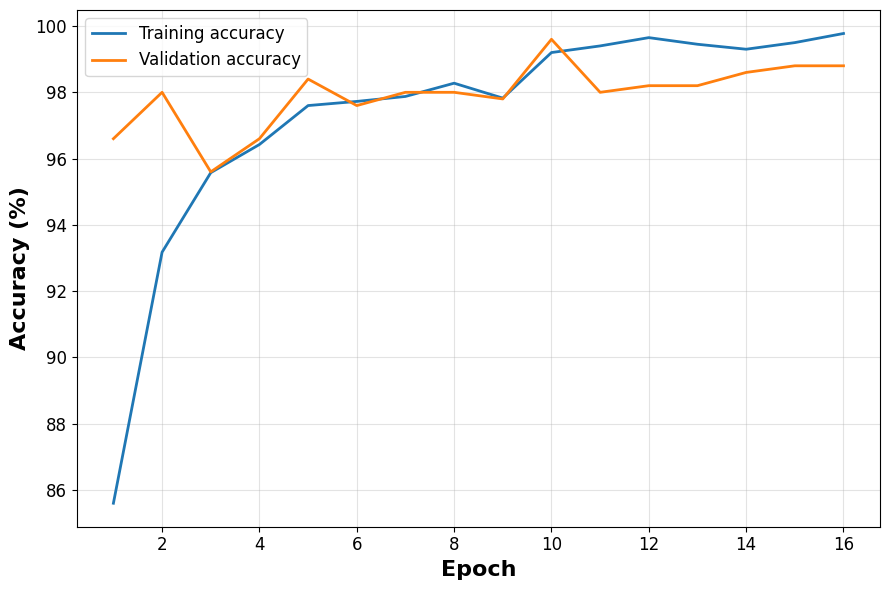

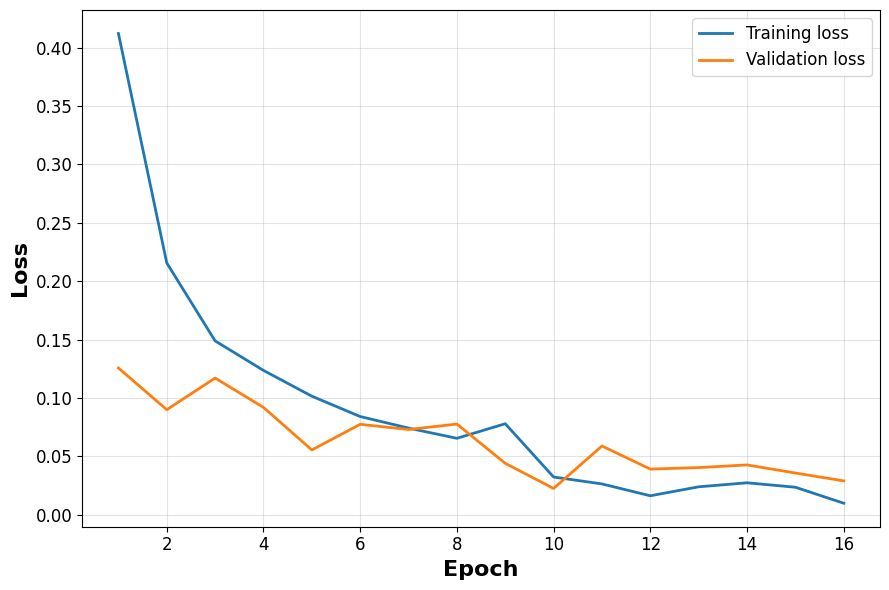

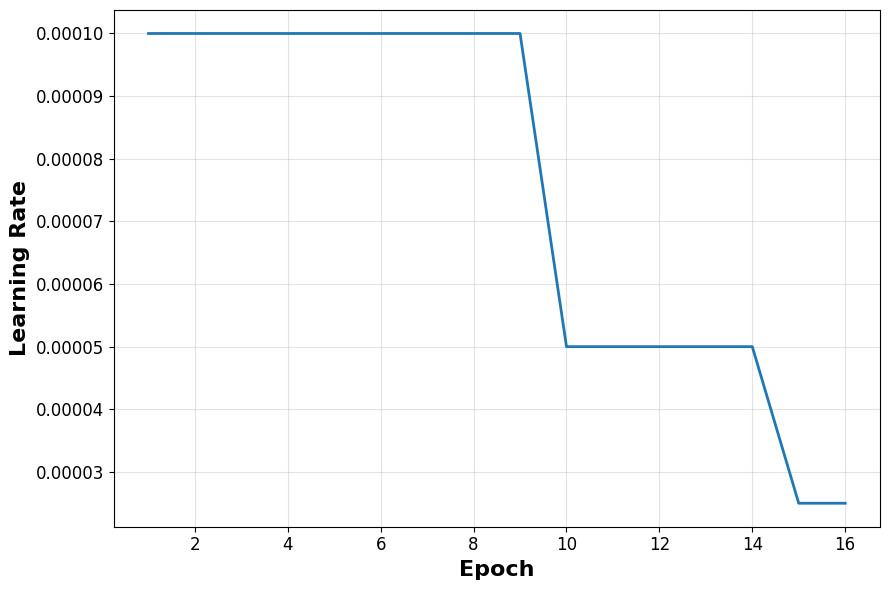

Görbék mentve.


In [ ]:
def save_accuracy_plot(history, save_path):
    epochs = range(1, len(history["train_acc"]) + 1)

    train_acc = np.array(history["train_acc"]) * 100
    val_acc = np.array(history["val_acc"]) * 100

    plt.figure(figsize=(9, 6))
    plt.plot(epochs, train_acc, label="Training accuracy", linewidth=2)
    plt.plot(epochs, val_acc, label="Validation accuracy", linewidth=2)
    plt.xlabel("Epoch", fontsize=16, fontweight="bold")
    plt.ylabel("Accuracy (%)", fontsize=16, fontweight="bold")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def save_loss_plot(history, save_path):
    epochs = range(1, len(history["train_loss"]) + 1)

    train_loss = np.array(history["train_loss"])
    val_loss = np.array(history["val_loss"])

    plt.figure(figsize=(9, 6))
    plt.plot(epochs, train_loss, label="Training loss", linewidth=2)
    plt.plot(epochs, val_loss, label="Validation loss", linewidth=2)
    plt.xlabel("Epoch", fontsize=16, fontweight="bold")
    plt.ylabel("Loss", fontsize=16, fontweight="bold")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, alpha=0.35)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

def save_lr_plot(history, save_path):
    epochs = range(1, len(history["lr"]) + 1)

    plt.figure(figsize=(9, 6))
    plt.plot(epochs, history["lr"], linewidth=2)
    plt.xlabel("Epoch", fontsize=16, fontweight="bold")
    plt.ylabel("Learning Rate", fontsize=16, fontweight="bold")
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

acc_plot_path = os.path.join(PLOTS_DIR, "accuracy_curve.png")
loss_plot_path = os.path.join(PLOTS_DIR, "loss_curve.png")
lr_plot_path = os.path.join(PLOTS_DIR, "lr_curve.png")

save_accuracy_plot(history, acc_plot_path)
save_loss_plot(history, loss_plot_path)
save_lr_plot(history, lr_plot_path)

print("Görbék mentve.")

18. rész — Teszt kiértékelés

Testing: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 63/63 [00:01<00:00, 42.06it/s]


Test accuracy: 0.99
              precision    recall  f1-score  support
glioma         0.982609  0.982609  0.982609   115.00
meningioma     0.984848  0.977444  0.981132   133.00
no_tumor       1.000000  1.000000  1.000000   106.00
pituitary      0.993197  1.000000  0.996587   146.00
accuracy       0.990000  0.990000  0.990000     0.99
macro avg      0.990164  0.990013  0.990082   500.00
weighted avg   0.989983  0.990000  0.989985   500.00
Classification report mentve: ./FNO_clas/DenseNet121_FourierLayer_final/tables/classification_report.csv


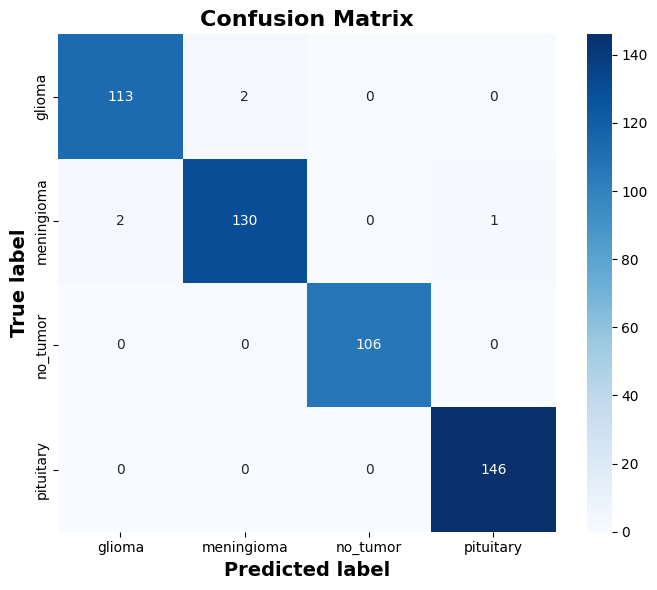

Confusion matrix mentve: ./FNO_clas/DenseNet121_FourierLayer_final/confusion_matrix/confusion_matrix.png


In [ ]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.eval()

y_true = []
y_pred = []
y_prob = []
test_paths = []

with torch.no_grad():
    for x, y, paths in tqdm(test_loader, desc="Testing"):
        x = x.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            out = model(x)

        probs = torch.softmax(out, dim=1)
        preds = out.argmax(dim=1).cpu().numpy()

        y_true.extend(y.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs.cpu().numpy())
        test_paths.extend(paths)

test_acc = accuracy_score(y_true, y_pred)
print("Test accuracy:", test_acc)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report_dict).transpose()

report_csv_path = os.path.join(TABLE_DIR, "classification_report.csv")
report_df.to_csv(report_csv_path, index=True)

print(report_df)
print("Classification report mentve:", report_csv_path)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted label", fontsize=14, fontweight="bold")
plt.ylabel("True label", fontsize=14, fontweight="bold")
plt.title("Confusion Matrix", fontsize=16, fontweight="bold")
plt.tight_layout()

cm_path = os.path.join(CM_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix mentve:", cm_path)

19. rész — Eredménytábla

In [ ]:
prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=[0, 1, 2, 3], zero_division=0
)

rows = []
for i, cls in enumerate(CLASS_NAMES):
    rows.append({
        "Model": "DenseNet121 + FourierLayer",
        "Class": cls,
        "Precision": f"{prec[i]:.4f}",
        "Recall": f"{rec[i]:.4f}",
        "F1-Score": f"{f1[i]:.4f}",
        "Support": int(support[i]),
        "Accuracy": "-"
    })

macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

rows.append({
    "Model": "",
    "Class": "Macro Avg",
    "Precision": f"{macro_p:.4f}",
    "Recall": f"{macro_r:.4f}",
    "F1-Score": f"{macro_f1:.4f}",
    "Support": int(np.sum(support)),
    "Accuracy": "-"
})
rows.append({
    "Model": "",
    "Class": "Weighted Avg",
    "Precision": f"{weighted_p:.4f}",
    "Recall": f"{weighted_r:.4f}",
    "F1-Score": f"{weighted_f1:.4f}",
    "Support": int(np.sum(support)),
    "Accuracy": f"{test_acc:.4f}"
})

results_table_df = pd.DataFrame(rows)
table_csv_path = os.path.join(TABLE_DIR, "results_table.csv")
results_table_df.to_csv(table_csv_path, index=False)

print(results_table_df)
print("Táblázat CSV mentve:", table_csv_path)

                        Model         Class Precision  Recall F1-Score  \
0  DenseNet121 + FourierLayer        glioma    0.9826  0.9826   0.9826   
1  DenseNet121 + FourierLayer    meningioma    0.9848  0.9774   0.9811   
2  DenseNet121 + FourierLayer      no_tumor    1.0000  1.0000   1.0000   
3  DenseNet121 + FourierLayer     pituitary    0.9932  1.0000   0.9966   
4                                 Macro Avg    0.9902  0.9900   0.9901   
5                              Weighted Avg    0.9900  0.9900   0.9900   

   Support Accuracy  
0      115        -  
1      133        -  
2      106        -  
3      146        -  
4      500        -  
5      500   0.9900  
Táblázat CSV mentve: ./FNO_clas/DenseNet121_FourierLayer_final/tables/results_table.csv


20. rész — Táblázat képként mentése

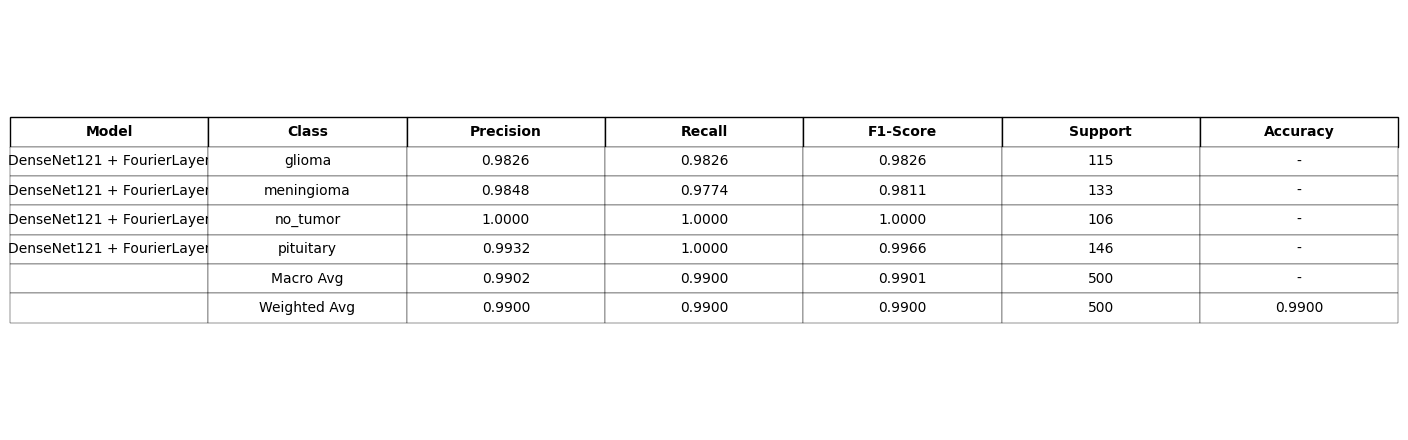

Táblázat kép mentve: ./FNO_clas/DenseNet121_FourierLayer_final/tables/results_table.png


In [ ]:
def save_table_image(df, save_path):
    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.15, 1.45)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_linewidth(1.0)
        else:
            cell.set_linewidth(0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

table_img_path = os.path.join(TABLE_DIR, "results_table.png")
save_table_image(results_table_df, table_img_path)

print("Táblázat kép mentve:", table_img_path)

21. rész — Preprocessing vizualizáció

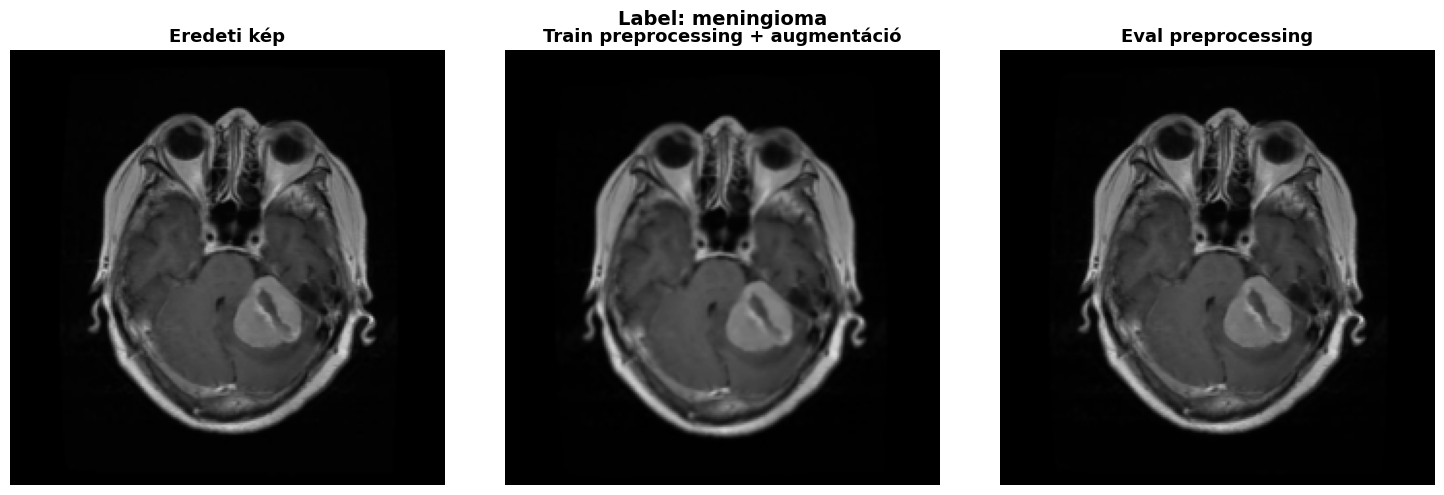

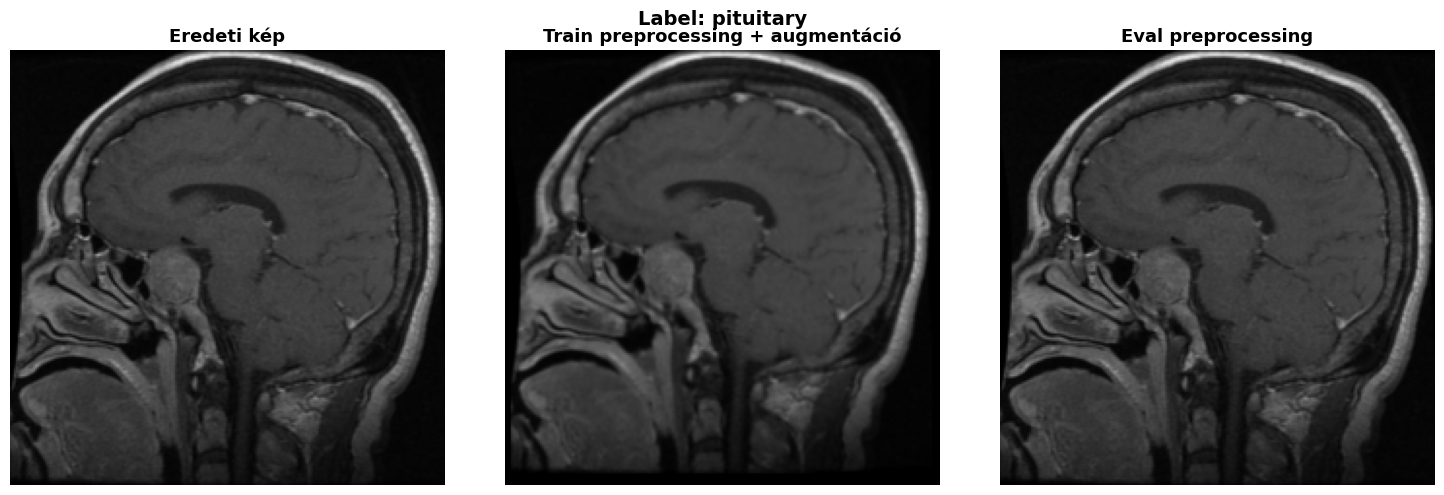

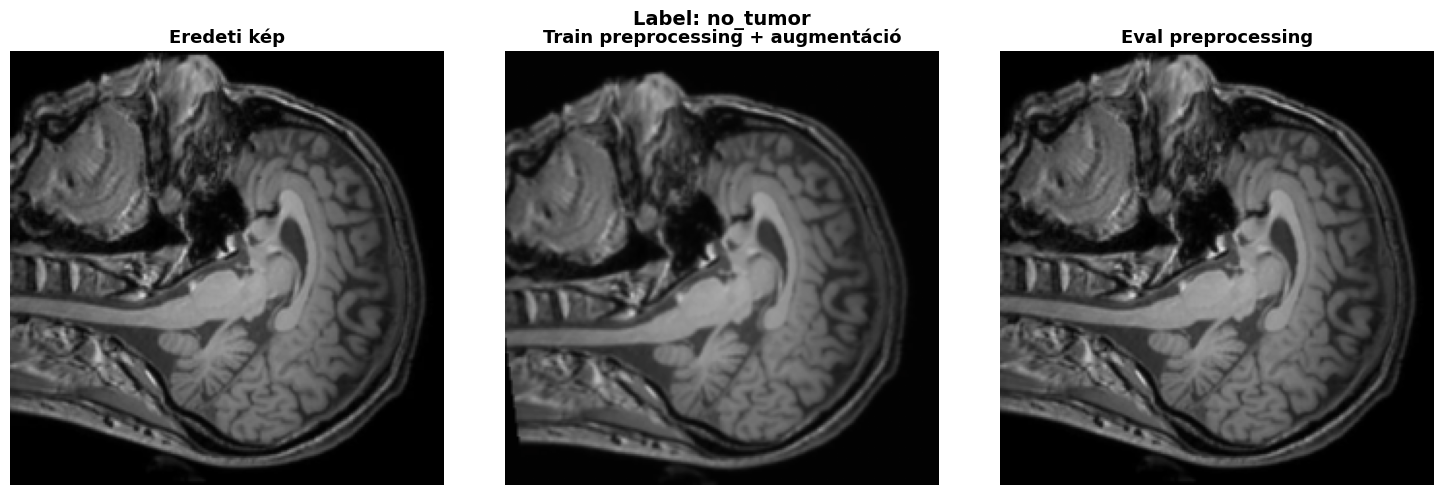

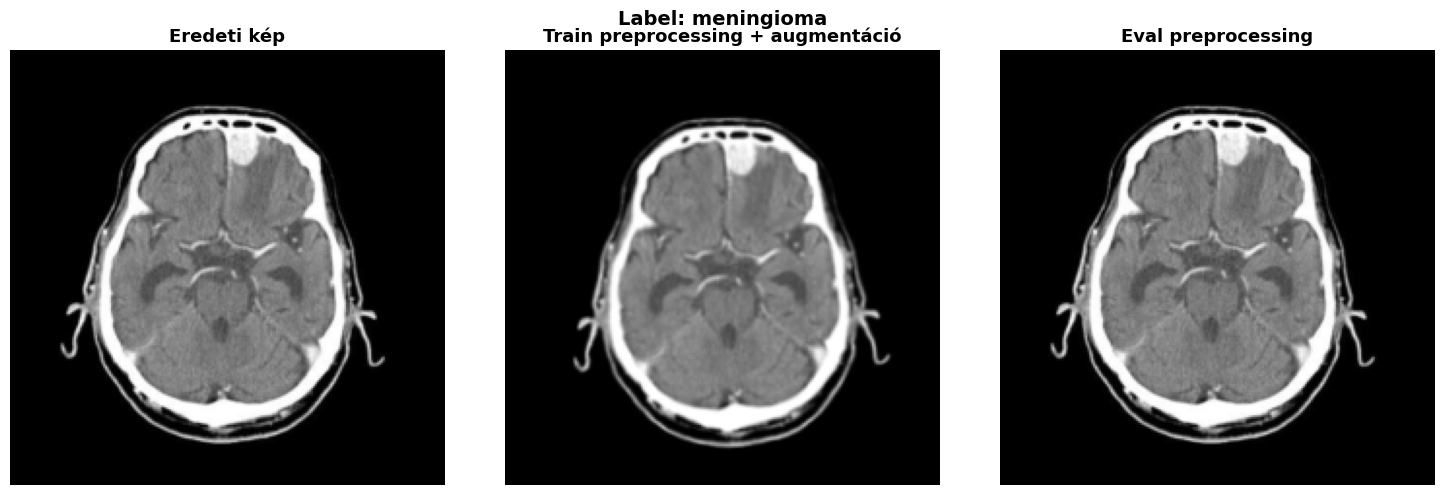

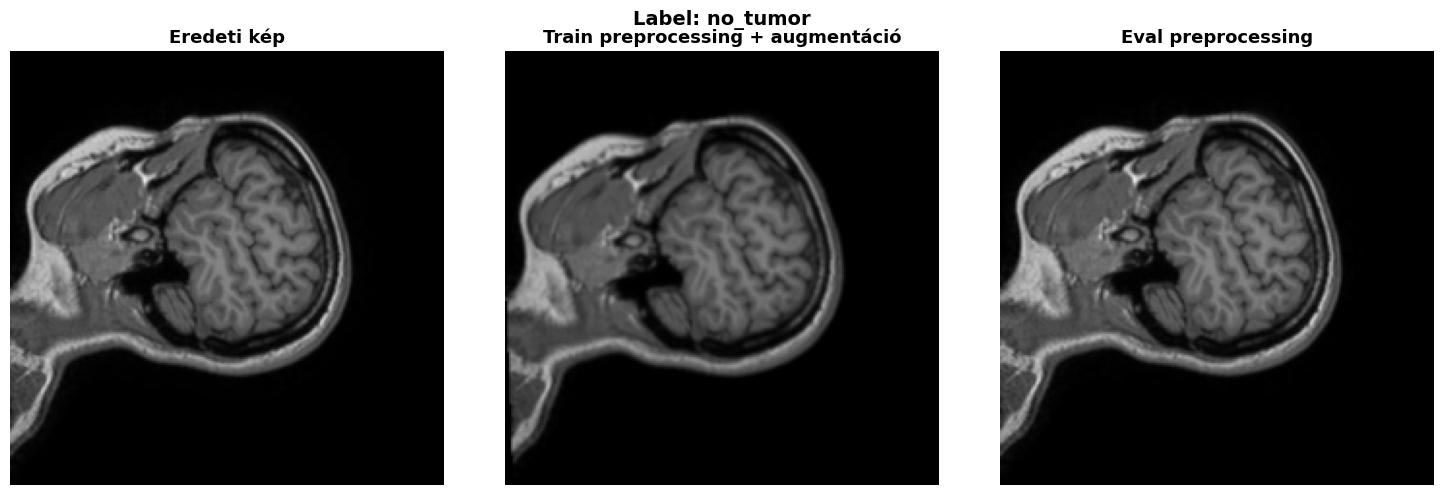

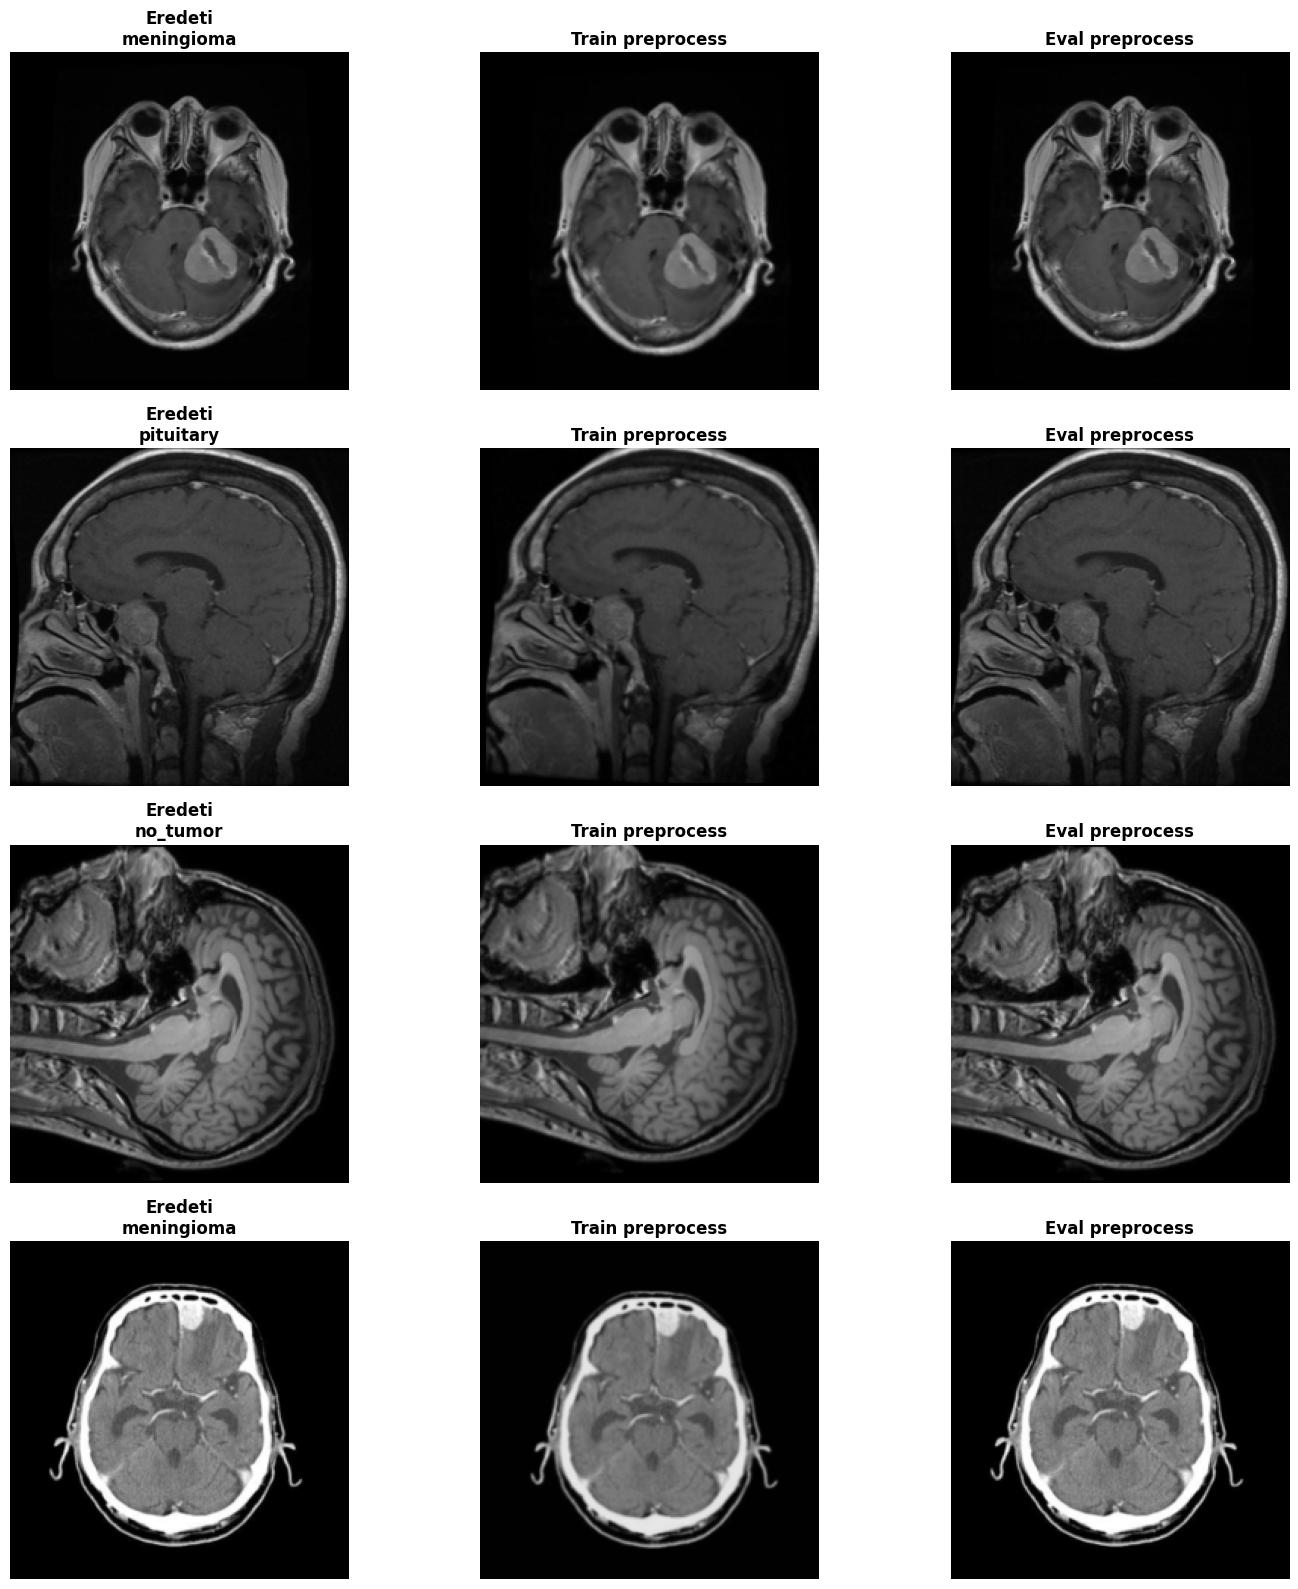

Preprocessing preview képek mentve ide: ./FNO_clas/DenseNet121_FourierLayer_final/preprocessing_preview


In [ ]:
def save_preprocessing_preview(dataframe, save_dir, num_images=5):
    sample_df = dataframe.sample(n=min(num_images, len(dataframe)), random_state=SEED).reset_index(drop=True)

    for i in range(len(sample_df)):
        row = sample_df.iloc[i]
        img_path = row["image_path"]
        label = row["label"]

        pil_img = Image.open(img_path).convert("RGB")

        original_vis = raw_vis_trans(pil_img)
        original_np = np.array(original_vis).astype(np.float32) / 255.0

        train_img = train_trans(pil_img)
        train_img_denorm = denormalize_image(train_img)
        train_np = tensor_to_numpy_img(train_img_denorm)

        eval_img = eval_trans(pil_img)
        eval_img_denorm = denormalize_image(eval_img)
        eval_np = tensor_to_numpy_img(eval_img_denorm)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(original_np)
        axes[0].set_title("Eredeti kép", fontsize=13, fontweight="bold")
        axes[0].axis("off")

        axes[1].imshow(train_np)
        axes[1].set_title("Train preprocessing + augmentáció", fontsize=13, fontweight="bold")
        axes[1].axis("off")

        axes[2].imshow(eval_np)
        axes[2].set_title("Eval preprocessing", fontsize=13, fontweight="bold")
        axes[2].axis("off")

        plt.suptitle(f"Label: {label}", fontsize=14, fontweight="bold")
        plt.tight_layout()

        save_path = os.path.join(save_dir, f"preprocessing_preview_{i+1}_{label}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
        plt.close()

def save_preprocessing_grid(dataframe, save_dir, num_images=4):
    sample_df = dataframe.sample(n=min(num_images, len(dataframe)), random_state=SEED).reset_index(drop=True)

    fig, axes = plt.subplots(len(sample_df), 3, figsize=(15, 4 * len(sample_df)))

    if len(sample_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(len(sample_df)):
        row = sample_df.iloc[i]
        img_path = row["image_path"]
        label = row["label"]

        pil_img = Image.open(img_path).convert("RGB")

        original_vis = raw_vis_trans(pil_img)
        original_np = np.array(original_vis).astype(np.float32) / 255.0

        train_img = train_trans(pil_img)
        train_np = tensor_to_numpy_img(denormalize_image(train_img))

        eval_img = eval_trans(pil_img)
        eval_np = tensor_to_numpy_img(denormalize_image(eval_img))

        axes[i, 0].imshow(original_np)
        axes[i, 0].set_title(f"Eredeti\n{label}", fontweight="bold")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(train_np)
        axes[i, 1].set_title("Train preprocess", fontweight="bold")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(eval_np)
        axes[i, 2].set_title("Eval preprocess", fontweight="bold")
        axes[i, 2].axis("off")

    plt.tight_layout()
    save_path = os.path.join(save_dir, "preprocessing_grid.png")
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

save_preprocessing_preview(df_test, PREPROCESS_DIR, num_images=5)
save_preprocessing_grid(df_test, PREPROCESS_DIR, num_images=4)

print("Preprocessing preview képek mentve ide:", PREPROCESS_DIR)

23. rész — Predikciók mentése

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_hook = target_layer.register_forward_hook(self.forward_hook)
        self.bwd_hook = target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inputs, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, class_idx):
        self.model.zero_grad()
        out = self.model(x)
        score = out[:, class_idx]
        score.backward()

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = cam.squeeze().detach().cpu().numpy()
        cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam

    def remove_hooks(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

label_map_inv = {0: "glioma", 1: "meningioma", 2: "no_tumor", 3: "pituitary"}

def save_gradcam_overlay(model, dataset, output_dir, num_images=8):
    model.eval()
    gradcam = GradCAM(model, model.reduce)

    chosen_indices = np.linspace(
        0,
        len(dataset) - 1,
        num=min(num_images, len(dataset)),
        dtype=int
    )

    for idx in chosen_indices:
        x, y, img_path = dataset[idx]
        input_tensor = x.unsqueeze(0).to(device)

        pred_logits = model(input_tensor)
        pred = pred_logits.argmax(dim=1).item()

        cam = gradcam.generate(input_tensor, pred)

        original_img = Image.open(img_path).convert("RGB")
        original_img = raw_vis_trans(original_img)
        original_np = np.array(original_img).astype(np.float32) / 255.0

        heatmap = np.uint8(255 * cam)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        overlay = 0.6 * original_np + 0.4 * heatmap
        overlay = np.clip(overlay, 0, 1)

        true_name = label_map_inv[y]
        pred_name = label_map_inv[pred]

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(original_np)
        axes[0].set_title(f"Original MRI\nTrue: {true_name}", fontsize=12, fontweight="bold")
        axes[0].axis("off")

        axes[1].imshow(cam, cmap="jet")
        axes[1].set_title(f"Grad-CAM\nPred: {pred_name}", fontsize=12, fontweight="bold")
        axes[1].axis("off")

        axes[2].imshow(overlay)
        axes[2].set_title("Overlay on MRI", fontsize=12, fontweight="bold")
        axes[2].axis("off")

        plt.tight_layout()

        save_path = os.path.join(
            output_dir,
            f"gradcam_{idx:03d}_true_{true_name}_pred_{pred_name}.png"
        )
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close()

    gradcam.remove_hooks()
    print(f"Grad-CAM képek mentve ide: {output_dir}")

save_gradcam_overlay(model, test_dataset, GRADCAM_DIR, num_images=8)

Grad-CAM képek mentve ide: ./FNO_clas/DenseNet121_FourierLayer_final/gradcam


In [ ]:
report_path = PROJECT_DIR

23. rész — Predikciók mentése

In [ ]:
pred_df = pd.DataFrame({
    "image_path": test_paths,
    "y_true": y_true,
    "y_pred": y_pred,
    "true_label": [label_map_inv[x] for x in y_true],
    "pred_label": [label_map_inv[x] for x in y_pred]
})

for i, cls in enumerate(CLASS_NAMES):
    pred_df[f"prob_{cls}"] = [p[i] for p in y_prob]

pred_csv_path = os.path.join(TABLE_DIR, "test_predictions.csv")
pred_df.to_csv(pred_csv_path, index=False)
print("Teszt predikciók mentve:", pred_csv_path)

Teszt predikciók mentve: ./FNO_clas/DenseNet121_FourierLayer_final/tables/test_predictions.csv


24. rész — Összegzés fájlba

In [ ]:
summary_path = os.path.join(PROJECT_DIR, "summary.txt")

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("DenseNet121 + FourierLayer eredmények\n")
    f.write(f"Best validation accuracy: {best_val_acc:.4f}\n")
    f.write(f"Best epoch: {best_epoch}\n")
    f.write(f"Test accuracy: {test_acc:.4f}\n")
    f.write(f"Tanítható paraméterek száma: {trainable_params}\n")
    f.write(f"Teljes tanítási idő (s): {training_wall_time_sec:.2f}\n")
    if len(history["epoch_time_sec"]) > 0:
        f.write(f"Átlag epoch idő (s): {np.mean(history['epoch_time_sec']):.2f}\n\n")
    else:
        f.write("Átlag epoch idő (s): n/a\n\n")

    f.write("Alkalmazott preprocessing:\n")
    f.write("- Resize 224x224\n")
    f.write("- RandomRotation(8)\n")
    f.write("- RandomAffine kis eltolással és skálázással\n")
    f.write("- ColorJitter brightness/contrast\n")
    f.write("- AddGaussianNoise\n")
    f.write("- ImageNet normalization\n\n")

    f.write("Mit csinál a kód:\n")
    f.write("1. Betölti a BRISC 2025 classification adatokat\n")
    f.write("2. Train/validation/test splitet készít\n")
    f.write("3. MRI-barát augmentációt alkalmaz a train adatokon\n")
    f.write("4. DenseNet121 feature extractort használ\n")
    f.write("5. FourierLayer fejet illeszt a DenseNet feature mapekre, ahol a Conv2D és a SpectralConv2d párhuzamosan fut\n")
    f.write("6. Betanítja a modellt early stoppinggal\n")
    f.write("7. Kiértékeli a modellt a teszt adatokon\n")
    f.write("8. Elmenti a confusion matrixet és a classification reportot\n")
    f.write("9. Grad-CAM magyarázó képeket készít\n")
    f.write("10. Eredeti vs preprocesselt képeket ment\n\n")

    f.write("Mentett fájlok:\n")
    f.write(f"- Best model: {BEST_MODEL_PATH}\n")
    f.write(f"- Last model: {FINAL_MODEL_PATH}\n")
    f.write(f"- Accuracy plot: {acc_plot_path}\n")
    f.write(f"- Loss plot: {loss_plot_path}\n")
    f.write(f"- LR plot: {lr_plot_path}\n")
    f.write(f"- Confusion matrix: {cm_path}\n")
    f.write(f"- Classification report: {report_path}\n")
    f.write(f"- Results table: {table_csv_path}\n")

print("Összegzés mentve:", summary_path)

Összegzés mentve: ./FNO_clas/DenseNet121_FourierLayer_final/summary.txt
